---
title: Coalescent conditioned on a derived variant
---

In [1]:
import phasic
from phasic import (
    Graph, StateIndexer, Property, SparseObservations, ExpStepSize, configure,
    GaussPrior, LogGaussPrior, BetaPrior, HalfCauchyPrior, Adamelia, dense_to_sparse,
)
import numpy as np
from itertools import combinations_with_replacement
from functools import partial
all_pairs = partial(combinations_with_replacement, r=2)
from scipy.stats import binom
from scipy.stats import beta
from vscodenb import set_vscode_theme
set_vscode_theme()

In [112]:
configure(parallel_elimination=True, 
          reward_compute_cache=False, 
          graph_cache=False,
#          high_precision_mode='never',
          )
#phasic.get_config().effective()

In [212]:
def coalescent_with_derived(state, indexer=None, N=None):
    transitions = []

    # callback params are always float
    N = int(N)

    # derived and total live lineages
    n_anc, n_der = 0, 0
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            n_der += state[i]
        else:
            n_anc += state[i]
    n_live = n_der + n_anc

    if n_live == 1:
        # absorbing state
        return []

    # pop derived freq
    freq = int(state[indexer.derived_freq])

    for i, j in all_pairs(range(indexer.lineages.state_length)):

        # props of lineage types at index i and j
        pi = indexer.lineages.i2p(i)
        pj = indexer.lineages.i2p(j)

        # both either anc or der
        same_ancestry = bool(pi.is_derived) == bool(pj.is_derived) and freq > 0

        # only coalesce derived and ancestral if derived is lost from population (implies the derived is now ancestral too)
        if not same_ancestry and freq > 0:
            continue

        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        is_derived = pi.is_derived if same_ancestry else 0 # can only be 0 if this is the final coalescence
        k = indexer.lineages.p2i(descendants=pi.descendants+pj.descendants, is_derived=is_derived)
        new[k] += 1

        pair_count = state[i] * (state[j] - same) / (1 + same)
        assert pair_count >= 1

        # if pi.is_derived and pj.is_derived:
        #     allele_N = freq
        # else:
        #     allele_N = N
        # # coef = [pair_count * (N/allele_N), 0, 0, 0, 0] 
        # coef = [pair_count * (N/allele_N), 0, 0, 0, 0] 

        if pi.is_derived and pj.is_derived:
            norm_freq = freq / N
        else:
            norm_freq = 1
        # coef = [pair_count * (N/allele_N), 0, 0, 0, 0] 
        coef = [pair_count * norm_freq, 0, 0, 0, 0] 

        transitions.append([new, coef])

    # transitions to sister states with other derived population frequencies
    if n_live > 1 and freq > 0:

        # forwards death derived, birth ancestral
        f = freq + 1
        if f <= N:# and not (f == N and n_anc > 0):
            new = state.copy()
            new[indexer.derived_freq] = f
            coef = [0, freq, freq**2, 0, 0]
            transitions.append([new, coef])

        # forwards death ancestral, birth derived
        f = freq - 1 # pos sel *reduces* freq backwards in time
        if not (n_der > 1 and f == 0): # der freq an only go to zero when a single der lineage remains
            new = state.copy()
            new[indexer.derived_freq] = f
            # coef = [0, (1 - s) * freq * (N - freq) / N]
            # coef = [0, (1 - s) * freq * (N - freq) / N]
            # coef = [0, (1 - s) * freq/N * (N - freq)]
            # coef = [0, (1 - s) * freq - freq*freq/N]
            # coef = [0, (1 - s) * freq - freq*freq/N - (s*freq - s*freq*freq/N)]
            # coef = [0, freq - freq*freq/N - s*freq + s*freq*freq/N)]
            # coef = [0, freq + freq*freq*(-1/N) + (-s)*freq + (s/N)*freq*freq)]
            coef = [0,     freq, freq**2, freq, freq**2]
            transitions.append([new, coef])

    return transitions

N = 100  # NB: for now N is fixed because it is also passed to the callback as argument

n_ancestral = 1
n_derived = 1
n_samples = n_ancestral + n_derived

s = 0

indexer = StateIndexer(
    "derived_freq",
    lineages=[
        Property('descendants', min_value=1, max_value=max(n_samples, n_derived)),        
        Property('is_derived', min_value=0, max_value=1),        
        ],
)
freqs = np.arange(1, N, dtype=int)
post = beta(1 + n_derived, 1 + (n_samples - n_derived)) # uniform prior
rates = np.array([post.pdf(f/N) for f in freqs])

rates = rates / (np.sum(rates) + 1e-12)

ipv = []
for i in range(len(freqs)):
    state = [0] * indexer.state_length
    state[indexer.lineages.props_to_index(descendants=1, is_derived=0)] = n_samples - n_derived
    state[indexer.lineages.props_to_index(descendants=1, is_derived=1)] = n_derived
    state[indexer.derived_freq] = freqs[i]
    ipv.append([state, rates[i]])

graph = Graph(coalescent_with_derived, ipv=ipv, indexer=indexer, N=N)
_N = 2*N
_s = -s
# coef = [0, freq + freq*freq*(-1/N) + (-s)*freq + (s/N)*freq*freq)]
graph.update_weights([1/_N, 1, -1/_N, -_s, _s/_N])
graph.expectation()    


305.302303258081

In [ ]:
graph.plot(size=(15, 15), max_nodes=300)

Graph has too many nodes (401). Please set max_nodes to a higher value.


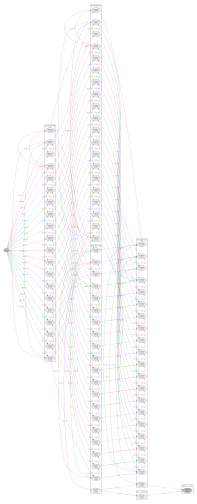

In [50]:
graph.plot(
    subgraphfun=lambda state: str(state[:-1]),
    ranksep=5,
    )

In [21]:
graph.vertices_length()

45

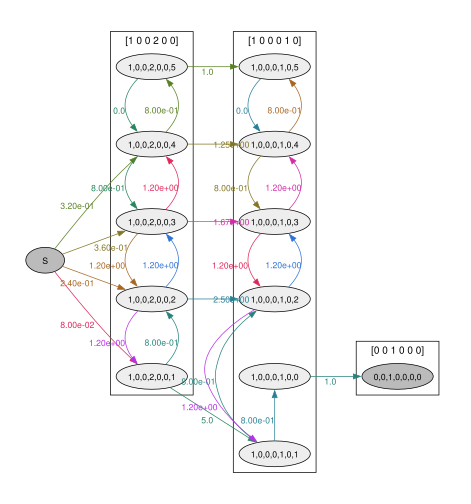

In [ ]:
graph.plot_scc_decomp();

In [5]:

def label(vertex):
    state = vertex.state()
    anc, der = 0, 0
    for i in range(indexer.lineages.state_length):
        p = indexer.lineages.i2p(i)
        if p.is_derived:
            der += state[i]
        else:
            anc += state[i]
    return f'{der} / {anc+der}, f:{state[indexer.derived_freq]}'

def subgr(state):
    s = state.tolist()
    del s[indexer.derived_freq]
    return s

graph.plot(subgraphfun=subgr, label_fmt=label)

NameError: name 'graph' is not defined

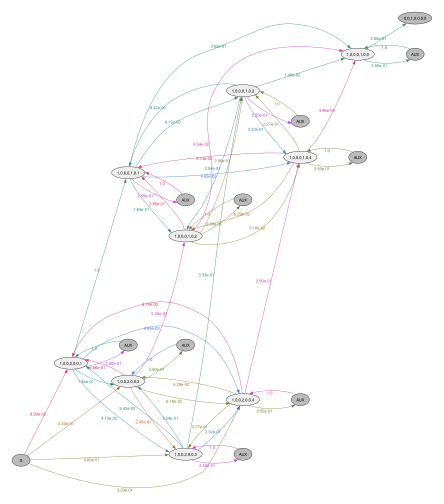

In [6]:
graph = cont_graph.discretize(rate=mutation_rate)

def weight_update(param, coef):
    N, s, u = param
    coal_rate_scalar, from_freq, to_freq, mut_scalar = coef

    if coal_rate_scalar > 0:
        return coal_rate_scalar / N
    elif mut_scalar:
        return u * mut_scalar
    else:
        _s = - s # s is negative because time is backwards
        N = int(round(N)) # binom.pmf wants integer N
        sampling_prob = from_freq/N * (1 + _s) / (1 + _s * from_freq/N)
        rate = binom.pmf(to_freq, N, sampling_prob)
        return rate

graph.update_weights(true_theta + [mutation_rate], callback=weight_update)
graph.plot()

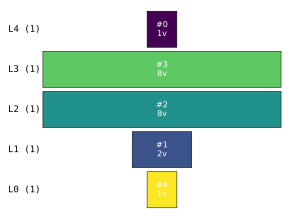

In [7]:
graph.plot_scc_decomp();

In [8]:
# with configure(parallel_elimination=True):
#     # cache parameterized reward compute for graph and its SCCs
#     graph.prewarm_cache()

In [9]:
graph.rewards

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [10]:
rewards = np.array(graph.states()).T
rewards[:, -1] = 0 # zero out absorbing
rewards[np.sum(rewards, axis=1) > 0] # only indexer slot representing actual states used

array([[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 2, 3, 4, 1, 2, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
      dtype=int32)

In [11]:

nr_observations = 1000
n = nr_observations
observed_data = np.zeros((n * (rewards.shape[0]), rewards.shape[0]), dtype=float)
observed_data[:] = np.nan
for i in range(rewards.shape[0]):
    observed_data[(i*n):((i+1)*n), i] = graph.sample(n, rewards=rewards[i])
np.random.shuffle(observed_data)
observed_data[:nr_observations] # just the first nr_observations rows
sparse_observations = dense_to_sparse(observed_data)
sparse_observations

RuntimeError: Expected vertex with index 3 (state 1 0 0 2 0 0 3) to have outgoing rate <= 1. Is '1.163525'. Are you sure this is a discrete phase-type distribution?


In [ ]:
#%%monitor
phasic.set_log_level('DEBUG')
svgd = graph.svgd(
    observed_data=sparse_observations, 
                  rewards=rewards, 
                  preconditioner='none',
                  callback=weight_update,
                  theta_dim=2,
                  fixed=[(0, pop_size)],
                  prior=[
                      None,
                      BetaPrior(ci=(0.01, 0.5)),
                  ],
                  n_iterations=20,                
                  n_particles=50,                
                learning_rate=ExpStepSize(first_step=0.01, last_step=0.001, tau=30.0),
                progress=True,
                      )                  

[DEBUG] phasic.c: Auto-selected granularity: 1024 (max_rate=512.00)
[DEBUG] phasic.c: Ill-conditioned multiplier detected: 5.32e-11 at command 515
[DEBUG] phasic.c: Conditioning summary: max_mult=1.40e+01, min_mult=3.82e-18, condition=3.67e+18 (576 ill-conditioned operations)
[DEBUG] phasic.c: Ill-conditioned multiplier detected: 5.32e-11 at command 515
[DEBUG] phasic.c: Conditioning summary: max_mult=1.40e+01, min_mult=3.82e-18, condition=3.67e+18 (576 ill-conditioned operations)
[DEBUG] phasic.svgd: SVGD.optimize: no preconditioner configured
[DEBUG] phasic.c: Auto-selected granularity: 1024 (max_rate=512.00)
[DEBUG] phasic.c: Ill-conditioned multiplier detected: 5.32e-11 at command 515
[DEBUG] phasic.c: Conditioning summary: max_mult=1.40e+01, min_mult=3.82e-18, condition=3.67e+18 (428 ill-conditioned operations)
[DEBUG] phasic.c: Ill-conditioned multiplier detected: 5.32e-11 at command 515
[DEBUG] phasic.c: Conditioning summary: max_mult=1.40e+01, min_mult=3.82e-18, condition=3.67e

In [ ]:
svgd.summary()

In [ ]:
svgd.plot_hdr()

In [ ]:
svgd.plot_trace()

In [ ]:
svgd.plot_convergence()

In [ ]:
svgd.plot_pairwise()

### No epochs joint prob

In [ ]:
joint_graph = graph.joint_prob_graph(mutation_rate=mutation_rate, reward_limit=reward_limit)
print(joint_graph.vertices_length())
joint_graph.plot(max_nodes=400, nodesep=0.2, ranksep=3, by_state=subgr)

In [ ]:
def sample_joint_observations(joint_graph, theta, nr_observations):
    joint_graph.update_weights(theta + [mutation_rate], callback=weight_update) 
    joint_prob_table = joint_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    observations = joint_prob_table.loc[sample, joint_prob_table.columns[:-1]].to_numpy().tolist()
    return observations

In [ ]:
observations = sample_joint_observations(joint_graph, true_theta + [mutation_rate], nr_observations=10000)
observations[:5]

In [ ]:
svgd = joint_graph.svgd(
    observed_data=observations, 
                  callback=weight_update,
                  theta_dim=3,
                #   fixed=[(2, mutation_rate)],
                #   prior=[
                #       GaussPrior(ci=[1, 5]),  
                #       HalfCauchyPrior(ci=0.3),
                #       None
                #   ],
                  n_iterations=20,                
                  n_particles=50,                
            # learning_rate=ExpStepSize(first_step=0.01, last_step=0.001, tau=30.0)
                 optimizer=Adamelia(learning_rate=0.2)
                      )



In [ ]:
svgd.summary()

In [ ]:
svgd.plot_hdr()

In [ ]:
svgd.plot_trace()

In [ ]:
svgd.plot_convergence()

In [ ]:
svgd.plot_pairwise()

In [ ]:

jp_graph = graph.joint_prob_graph(indexer, 
                                  reward_limit=reward_limit, 
                                  mutation_rate=mutation_rate)
jp_graph.update_weights(true_theta + [mutation_rate], callback=weight_update)
joint_prob_table = jp_graph.joint_prob_table()
(1 - joint_prob_table['prob'].sum()).item()

In [ ]:
jp_graph = graph.joint_prob_graph(indexer, 
                                  reward_limit=reward_limit, 
                                  mutation_rate=mutation_rate)
jp_graph.update_weights(true_theta + [mutation_rate])
joint_prob_table = jp_graph.joint_prob_table()
(1 - joint_prob_table['prob'].sum()).item()

In [ ]:

def sample_joint_observations(joint_prob_graph, theta, nr_observations):
    joint_prob_graph.update_weights(theta) 
    joint_prob_table = joint_prob_graph.joint_prob_table()
    p = joint_prob_table['prob'] / joint_prob_table['prob'].sum()
    p = p.to_numpy()
    sample = np.random.choice(joint_prob_table.index.values, nr_observations, p=p)
    observations = joint_prob_table.loc[sample, joint_prob_table.columns[:-1]].to_numpy().tolist()
    return observations

observations = sample_joint_observations(jp_graph, true_theta + [mutation_rate], nr_observations=10000)
observations[:5]


In [ ]:
nr_observations = 10000
observed_data = graph.sample(nr_observations, rewards=rewards)
observed_data

In [ ]:
%%monitor

svgd = joint_prob_graph.svgd(
    observed_data=observations, 
    callback=weight_update,
    # fixed=[(2, mutation_rate)],
    # n_iterations=100,
    # n_particles=200,
    # prior=[
    #     GaussPrior(ci=[5, 25]),
    #     GaussPrior(ci=[0, 3]),
    #     None
    # ],
    learning_rate=ExpStepSize(first_step=0.1, last_step=0.01, tau=50.0),
    )

svgd.summary()